In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb


# Jupyter visualization settings
%config InlineBackend.figure_format = 'retina'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [2]:
# load data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")
print(f'Dataset shape: {X.shape}, Target shape: {y.shape}')

Dataset shape: (150, 4), Target shape: (150,)


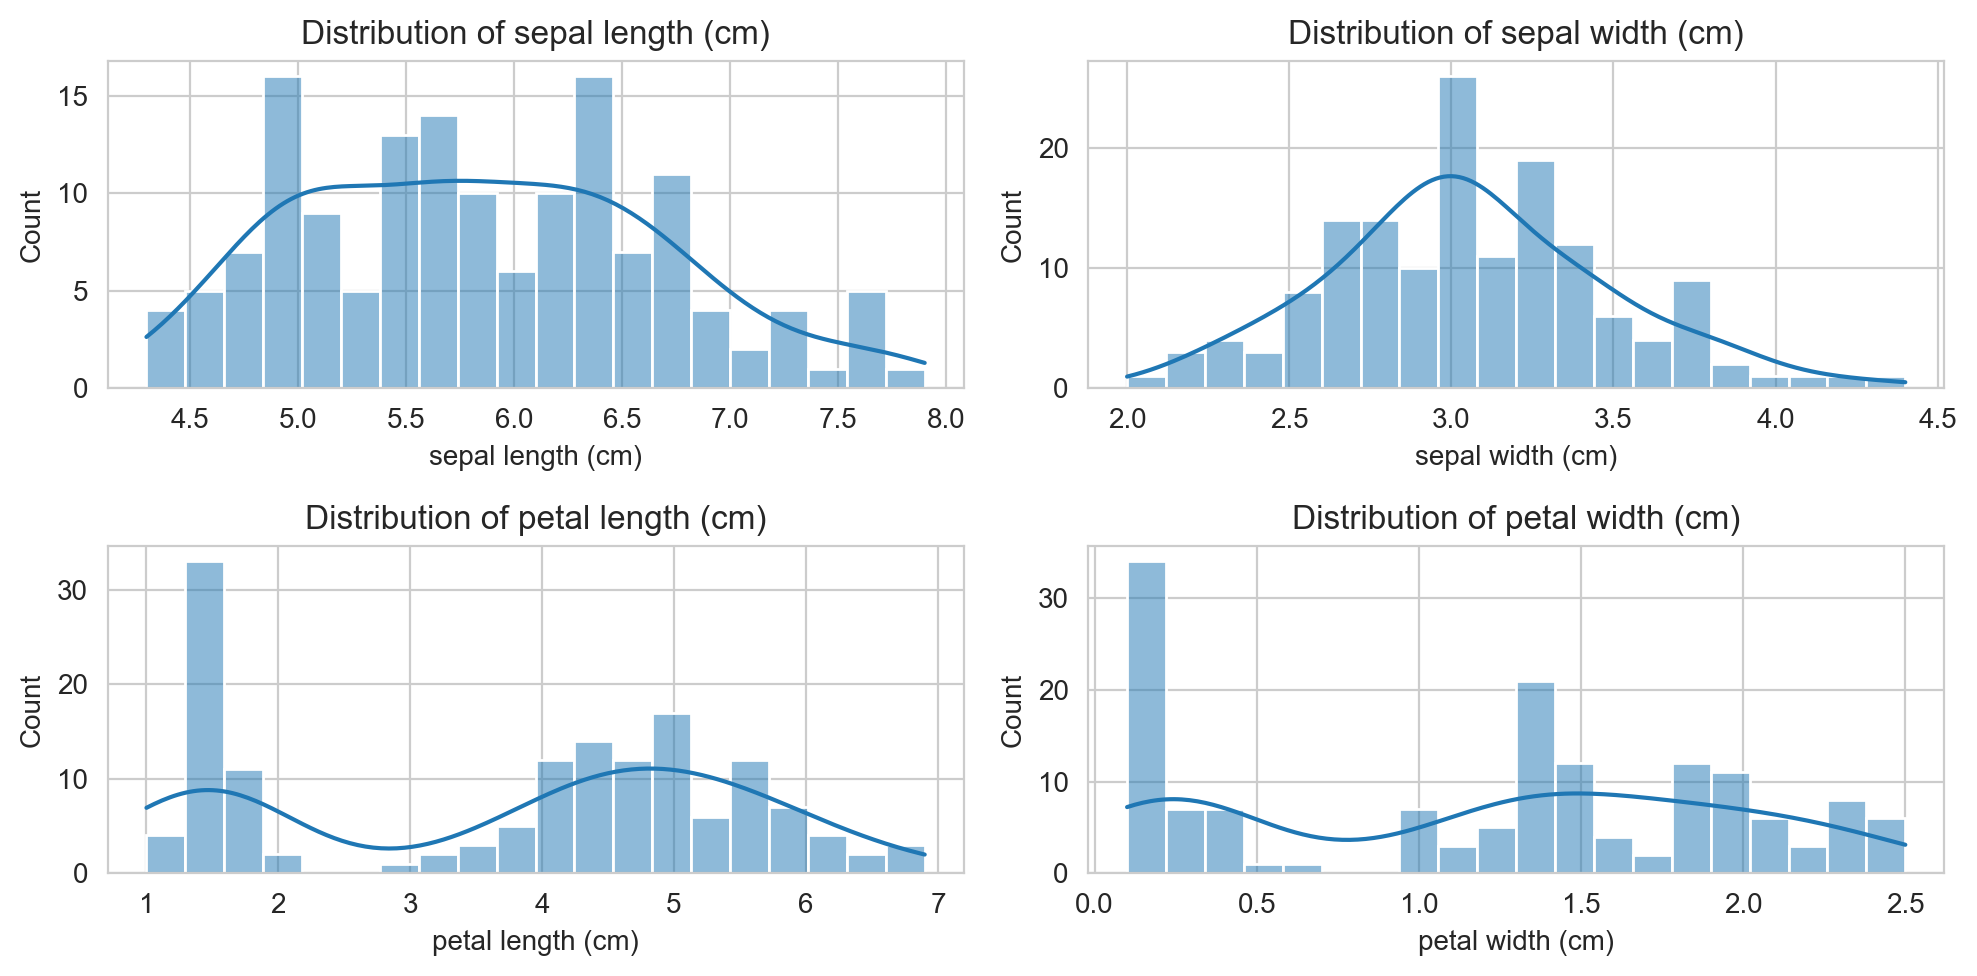

In [3]:
# Exploratory Data Analysis (EDA)
# show distribution of features
plt.figure(figsize=(10,5))
for i, col in enumerate(X.columns):
    plt.subplot(2,2,i+1)
    sns.histplot(X[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

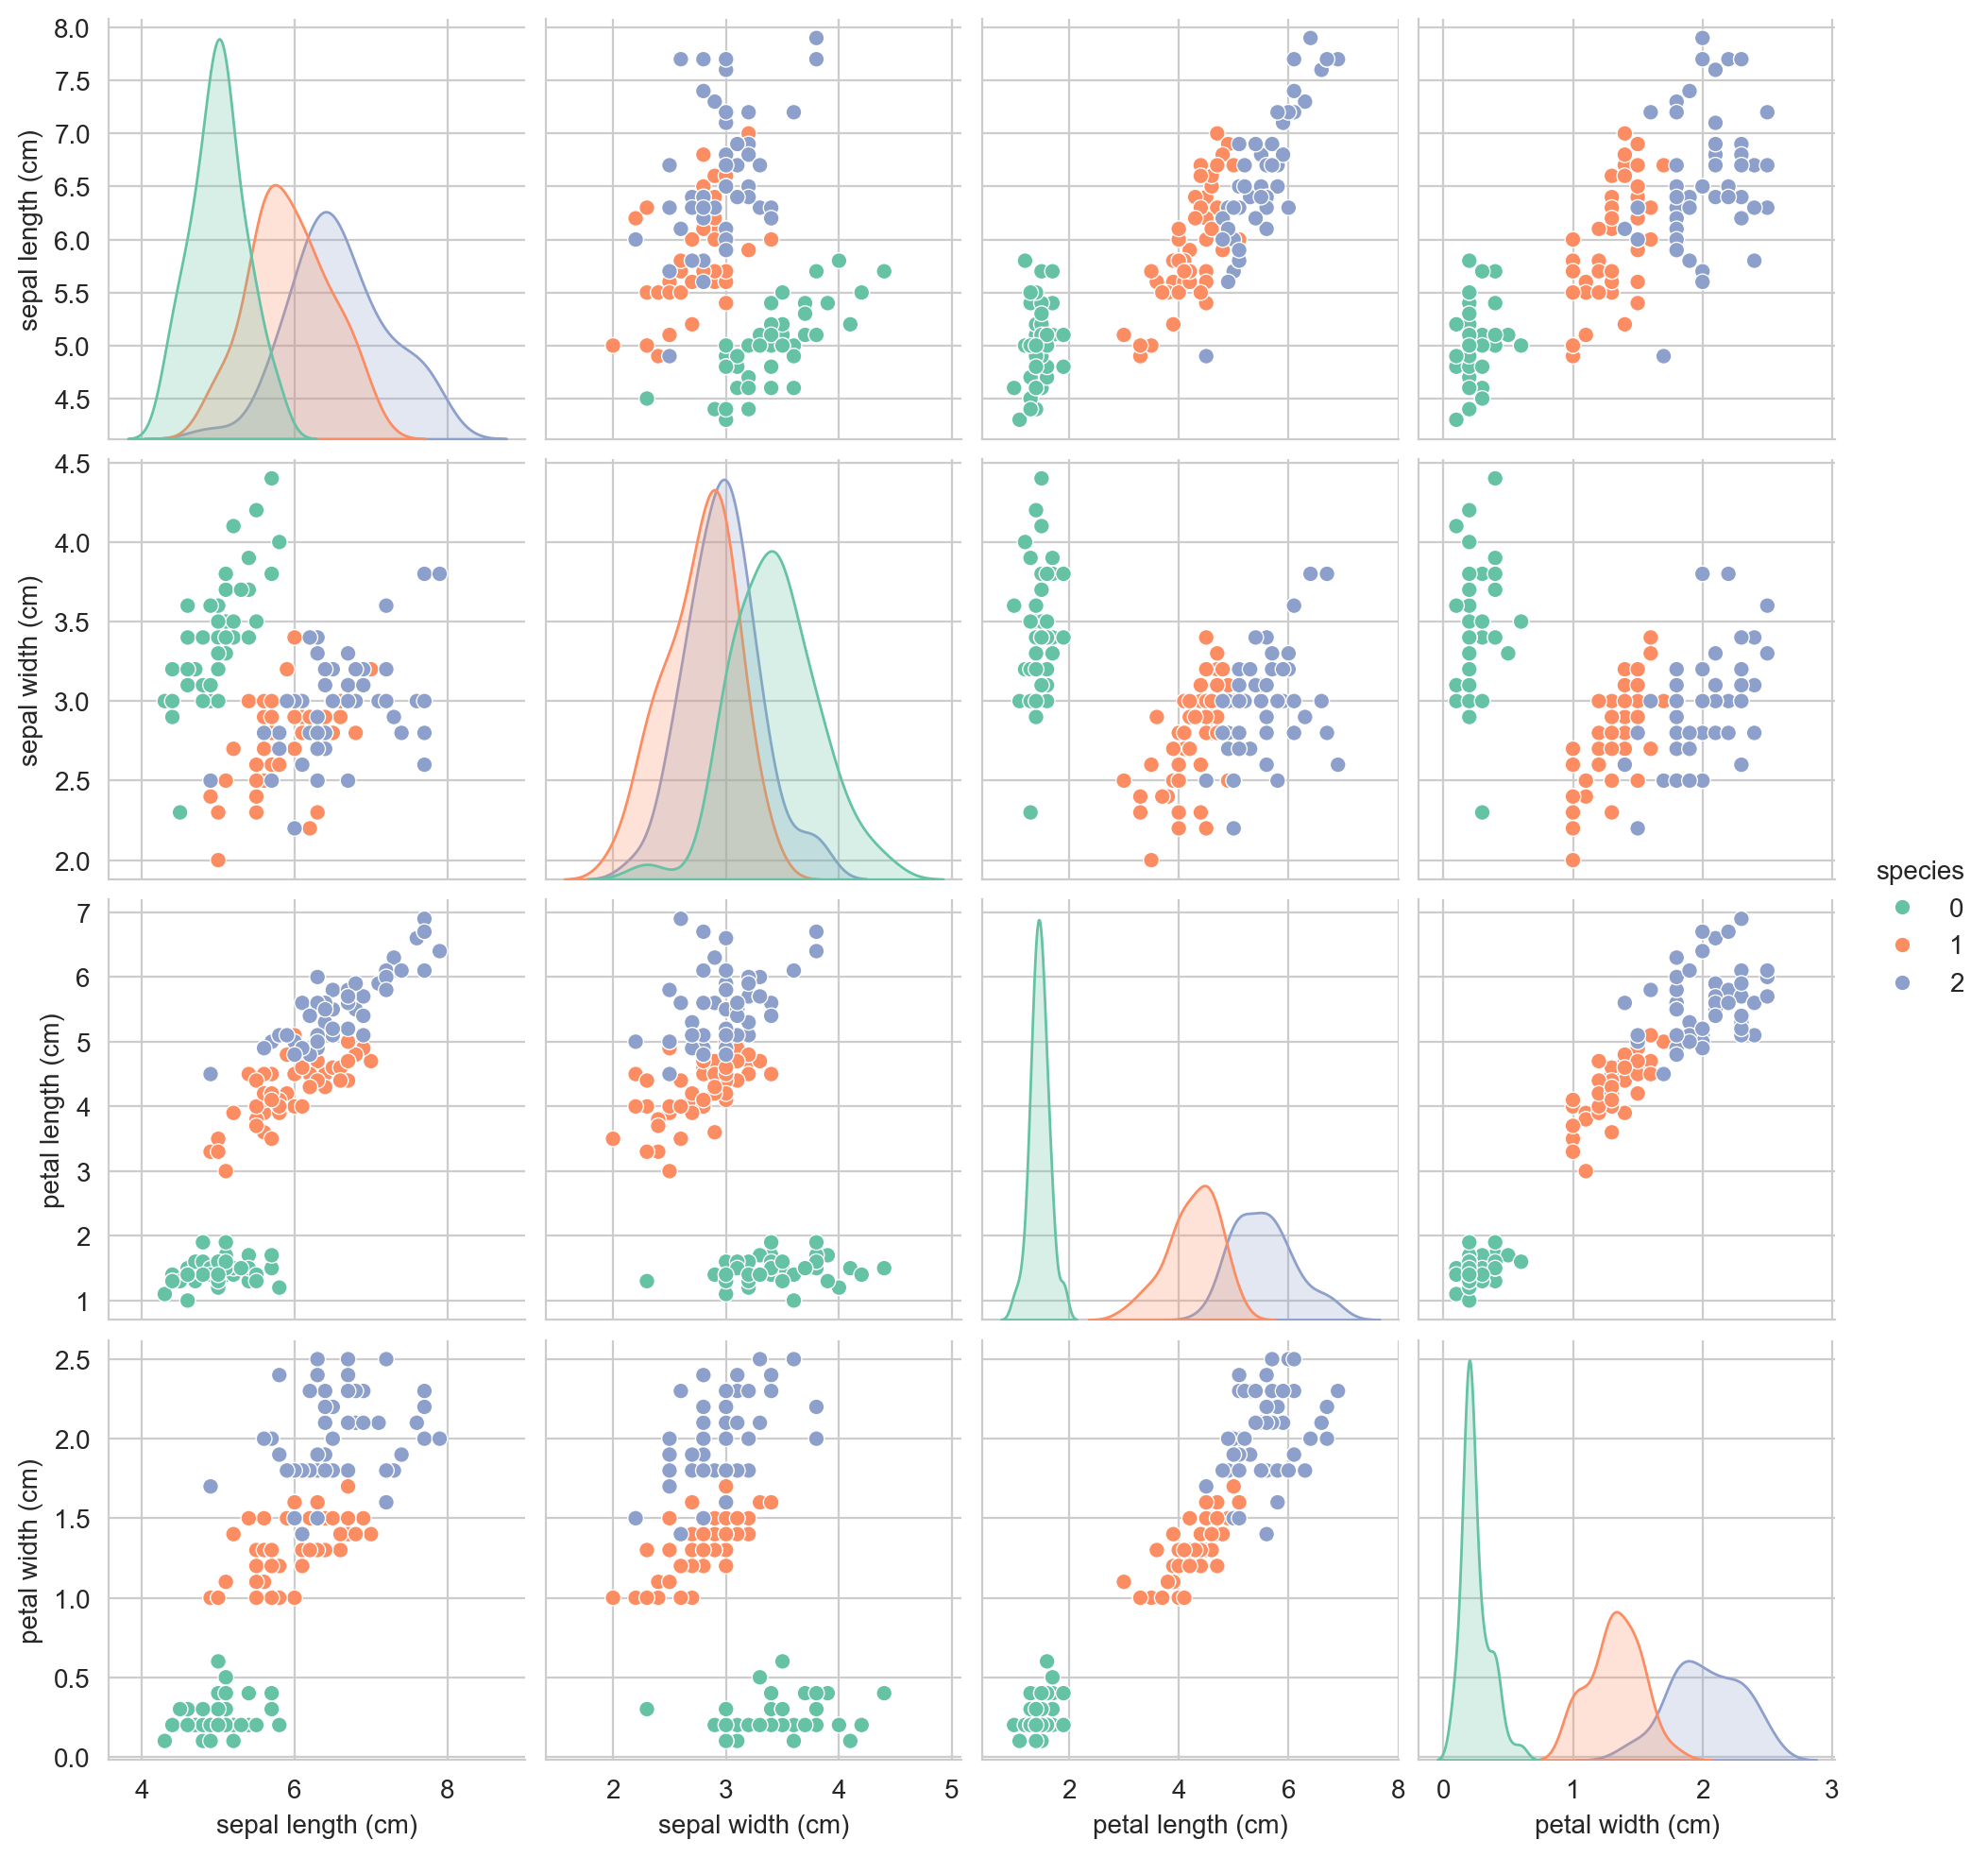

In [4]:
# pairplot to see relationships
plt.figure(figsize=(8,6))
sns.pairplot(pd.concat([X, y.rename('species')], axis=1), hue='species', palette="Set2")
plt.show()

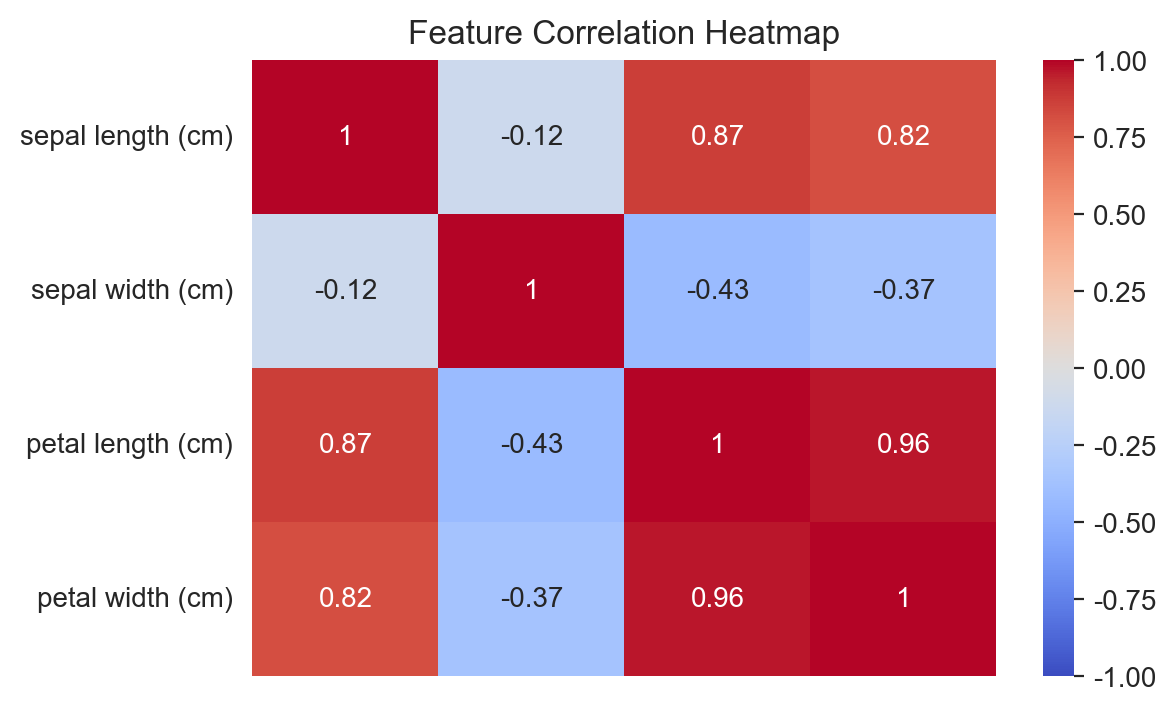

In [5]:
# correlation heatmap
plt.figure(figsize=(6,4))
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks([])
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
# split data and train initial model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

xgb_clf = xgb.XGBClassifier(objective='multi:softmax',
                            num_class=3,
                            eval_metric='mlogloss',
                            random_state=42)

Train shape: (120, 4), Test shape: (30, 4)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 150, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.9667
Classification Report after Optimization:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



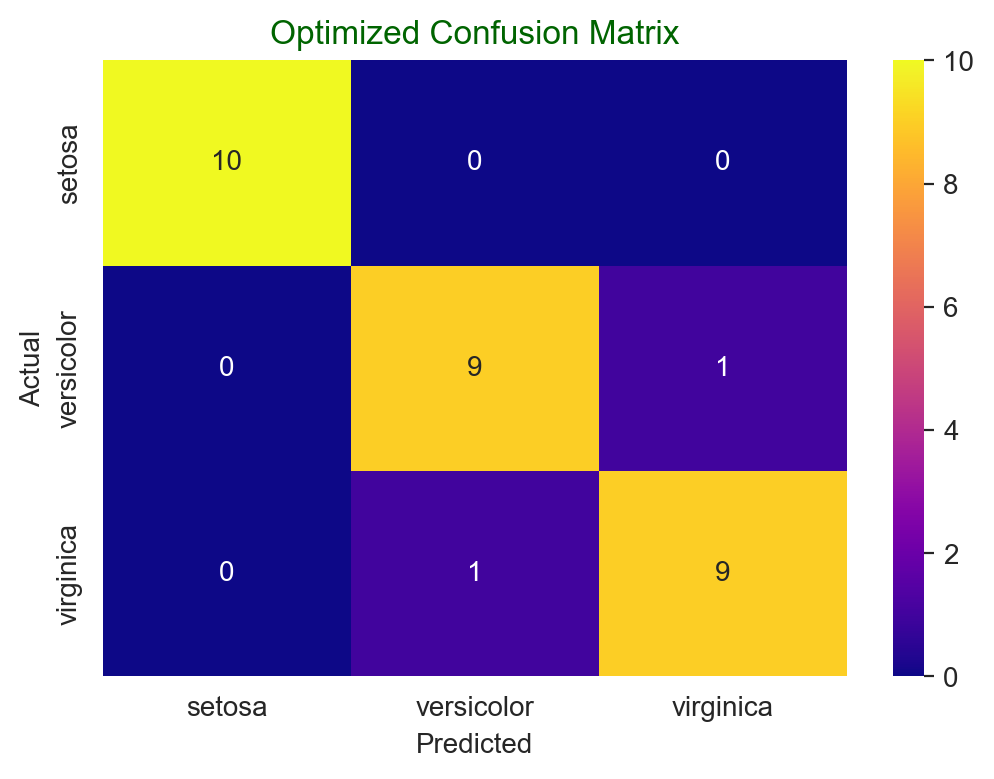

In [7]:
# hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f'Classification Report after Optimization:\n', classification_report(y_test, y_pred_best, target_names=iris.target_names))

cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='plasma', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Optimized Confusion Matrix', color='darkgreen')
plt.show()

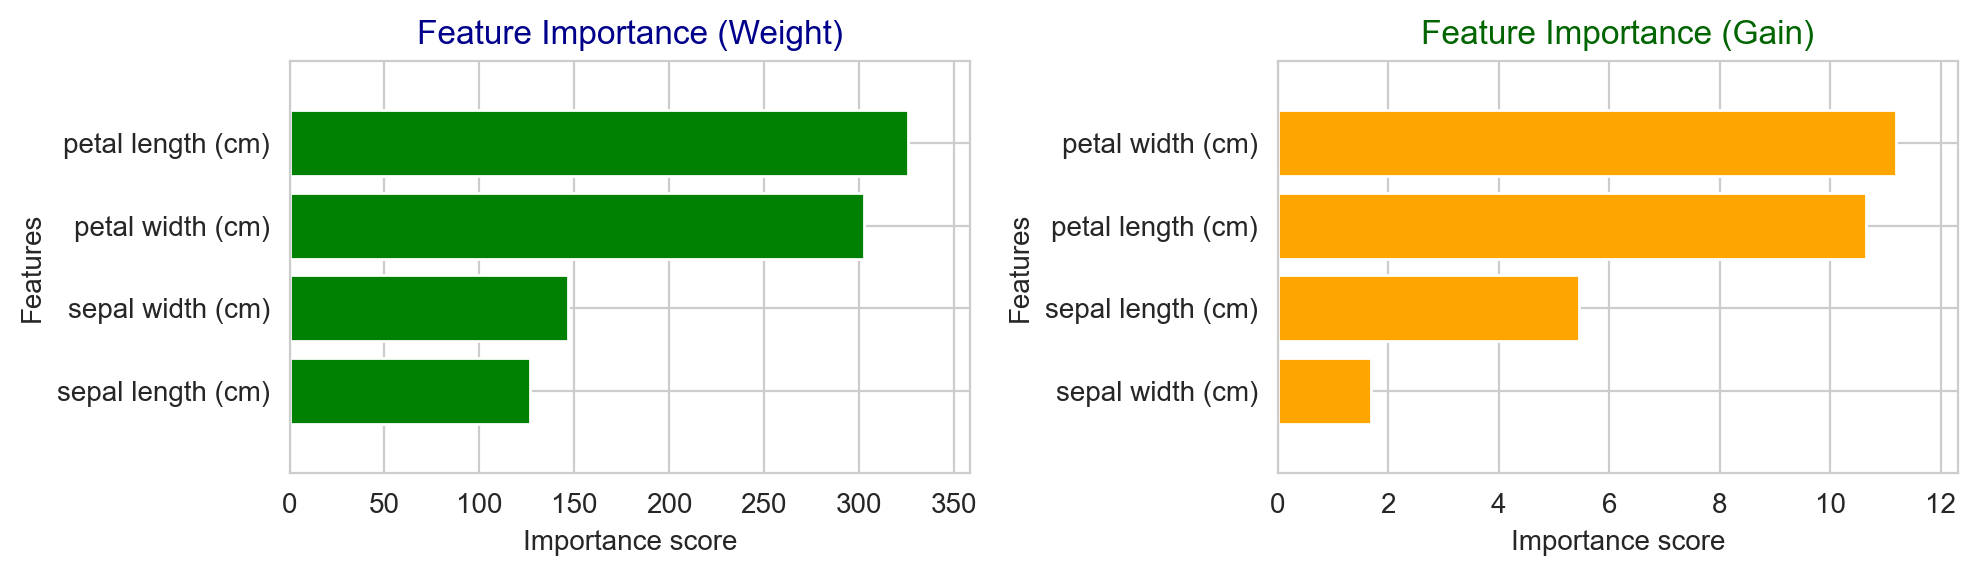

In [8]:
# Feature importance visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

xgb.plot_importance(best_xgb, importance_type='weight', max_num_features=10, height=0.8, color='green', ax=ax1, show_values=False)
ax1.set_title('Feature Importance (Weight)', color='darkblue')

xgb.plot_importance(best_xgb, importance_type='gain', max_num_features=10, height=0.8, color='orange', ax=ax2, show_values=False)
ax2.set_title('Feature Importance (Gain)', color='darkgreen')

plt.tight_layout()
plt.show()